# PROYECTO FINAL - MARKET INTELLIGENCE
## Análisis de Alojamientos en Chile para Inversión Hotelera

*Curso:* Big Data para la Toma de Decisiones  
*Profesora:* Vannessa Duarte  
*Grupo:* G5 - Turismo y Hotelería  
*Fecha:* Junio 2026  

---

##  Integrantes y Roles Organizacionales

| Integrante | Plataforma | Rol | Nivel |
|------------|------------|-----|-------|
| Lucas Cheuque | Kayak.cl | Ingeniero de Datos - PySpark | Nivel Táctico |
| Camila Rojas | Booking.com | Científica de Datos - Modelamiento/Clustering | Nivel Táctico |
| Martina Cortés | HotelsCombined | Analista de BI - Tableros & Storytelling | Nivel Estratégico |
| Bastián Bravo | Google Hotels | Especialista en Ingesta - Scrapers | Nivel Operativo |
| Juan Pablo Salas | Trip.com | Especialista en Ingesta - Scrapers | Nivel Operativo |
| Angelo Rojo | Denomades.com | Especialista en Ingesta - Scrapers | Nivel Operativo |
| Matías González | Airbnb.cl | Documentación y Calidad de Datos | Nivel Operativo |

##  Problemática

Una empresa del sector hotelero busca expandir sus operaciones a Chile y necesita información estratégica para decidir si invertir en el mercado de alojamientos. El desafío es entender la dinámica de precios, la distribución geográfica de la oferta y el nivel de competencia en las distintas regiones del país.

### Preguntas clave del negocio:

- ¿En qué ciudades hay sobrecompetencia?
- ¿Qué zonas tienen precios fuera de mercado?
- ¿Dónde existen oportunidades con baja oferta y alta demanda potencial?
- ¿Qué plataformas dominan cada región?

### Propuesta de Valor

Desarrollar un sistema de *Market Intelligence* que permita a una empresa hotelera evaluar la viabilidad de ingresar al mercado chileno, mediante el análisis de:

1. Distribución de precios por plataforma, ciudad y zona geográfica
2. Nivel de competencia (cantidad de alojamientos por localidad)
3. Oportunidades de mercado (zonas con baja oferta y alta demanda potencial)
4. Alertas de precios para evitar sobreprecios o subvaloración
5. Recomendaciones estratégicas para la entrada al mercado

##  Fuentes de Datos

*Origen:* MongoDB Atlas  
*Base de datos:* proyecto_bigdata  
*Colección:* alojamientos

### Plataformas de origen:

| Integrante | Plataforma |
|------------|------------|
| Lucas Cheuque | Kayak.cl |
| Camila Rojas | Booking.com |
| Matías González | Airbnb.cl |
| Martina Cortés | HotelsCombined |
| Bastián Bravo | Google Hotels |
| Juan Pablo Salas | Trip.com |
| Angelo Rojo | Denomades.com |

*Volumen de datos:* 3,584 alojamientos (registros válidos después de limpieza)

### Etiquetas extraídas por alojamiento:

| Campo | Tipo | Descripción |
|-------|------|-------------|
| nombre_hotel | String | Nombre del alojamiento |
| precio_clp | Float | Precio por noche en CLP |
| ciudad | String | Ciudad del alojamiento |
| zona_geografica | String | Norte, Centro, Sur, Patagonia, etc. |
| tipo_alojamiento | String | hotel, apartamento, hostal, cabaña |
| puntuacion | Float | Puntuación del alojamiento (0-10) |
| plataforma | String | Plataforma de origen |
| prediction | Integer | Cluster asignado (K-Means) |

##  Tabla de Indicadores Clave (KPIs)

### Métricas Generales

| Indicador | Valor |
|-----------|-------|
| Total de alojamientos | 3,584 |
| Precio promedio | $90,750 CLP |
| Puntuación promedio | 8.39 / 10 |
| Grupo 0 (oportunidad) | 42.8% |
| Ciudad con más oferta | Santiago |
| Tipo más común | Hotel |

### KPIs por Tipo de Alojamiento

| Tipo de Alojamiento | Cantidad | Precio Promedio (CLP) | Puntuación Promedio |
|---------------------|----------|----------------------|---------------------|
| apartamento | 416 | $83,634 | 8.32 |
| casa/cabaña | 385 | $89,940 | 8.37 |
| hostal | 818 | $47,521 | 8.36 |
| hotel | 1,965 | $110,410 | 8.42 |

---

### KPIs por Nivel Organizacional

| Nivel | KPI | Variable | Frecuencia | Objetivo de Negocio |
|-------|-----|----------|------------|---------------------|
| *Estratégico* | Concentración del mercado por ciudad | Ciudad, Cantidad | Mensual | Identificar ciudades con mayor/menor oferta |
| *Estratégico* | Distribución de tipos de alojamiento | Tipo, Cantidad | Mensual | Identificar formatos saturados y nichos disponibles |
| *Estratégico* | Participación por segmento (cluster) | Cluster, Cantidad | Mensual | Identificar el segmento con mayor demanda potencial |
| *Táctico* | Rango de precios por tipo | Tipo, Precio | Semanal | Definir estrategia de precios según tipo |
| *Táctico* | Precio promedio por ciudad | Ciudad, Precio | Semanal | Decidir en qué ciudad invertir |
| *Operacional* | Salud de la reputación | Puntuación, Cantidad | Diario | Identificar alojamientos con baja calidad |
| *Operacional* | Alertas por ciudad | Ciudad, Alertas | Diario | Concentrar revisión de calidad |

## 🏢 Nivel Estratégico (C-Level / Directivos)

### Gráfico 1: Concentración del mercado por ciudad

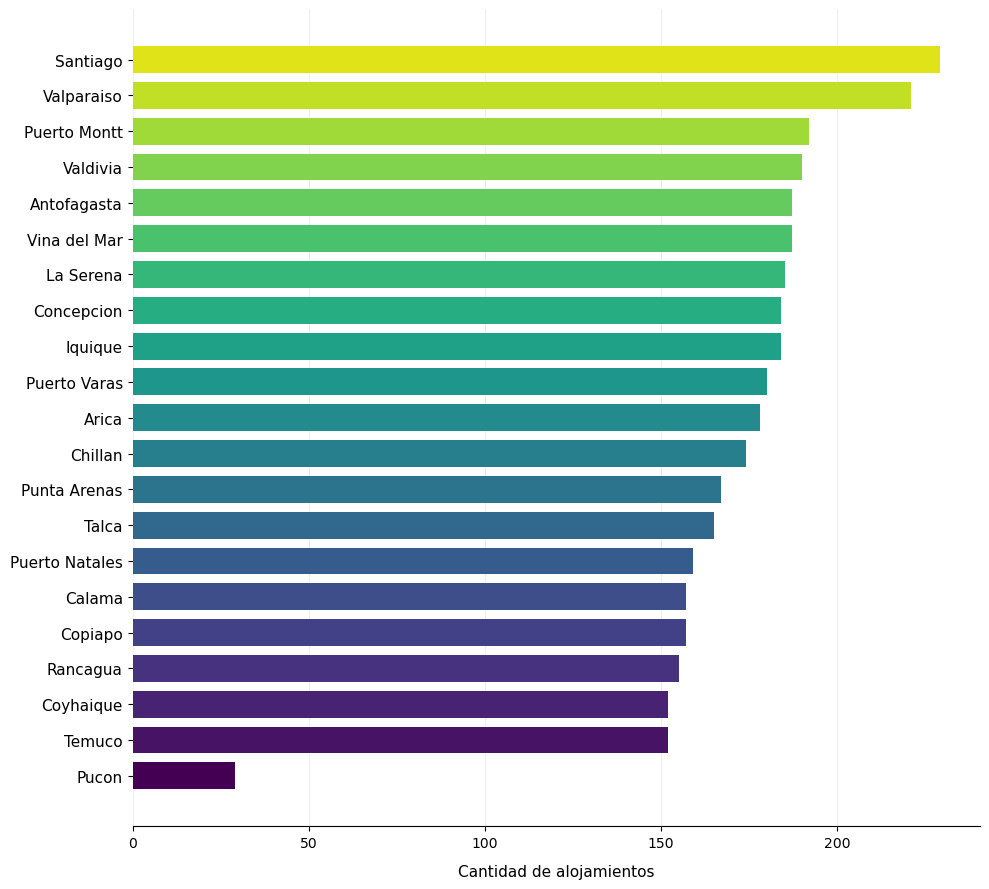

In [12]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm


spark = SparkSession.builder.appName("MarketIntelligence").getOrCreate()
df = spark.read.csv("datos_alojamientos_dashboard.csv", header=True, inferSchema=True)

if "precio_noche" in df.columns:
    df = df.withColumnRenamed("precio_noche", "precio_clp")


total = df.count()
kpi_ciudad = (df.groupBy("ciudad")
              .agg(F.count("*").alias("cantidad"))
              .withColumn("participacion", F.round(F.col("cantidad") / total * 100, 2))
              .orderBy(F.asc("cantidad"))) # Ascendente para el truco visual horizontal

pandas_ciudad = kpi_ciudad.toPandas()


fig, ax = plt.subplots(figsize=(10, 9))


valores_normalizados = [i / len(pandas_ciudad) for i in range(len(pandas_ciudad))]
colores_degradado = cm.viridis(valores_normalizados)


barras = ax.barh(pandas_ciudad["ciudad"], pandas_ciudad["cantidad"], color=colores_degradado, height=0.75)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_xlabel("Cantidad de alojamientos", fontsize=11, labelpad=10)
ax.tick_params(axis='y', labelsize=11)


ax.grid(axis="x", linestyle="-", alpha=0.3, color="#cccccc")
ax.set_axisbelow(True)

plt.tight_layout()


plt.show()

*Storytelling Estratégico:*

El mercado está repartido de forma pareja entre las ciudades; ninguna domina la oferta. La dirección concluye que hay espacio para invertir en distintos destinos, eligiendo por atractivo y rentabilidad, no por falta de competencia.

 *Decisión de Negocio:* Considerar ciudades con menor oferta para una entrada con menos competencia.

---

### Gráfico 2: Distribución de tipos de alojamiento

+----------------+--------+-------------+
|tipo_alojamiento|cantidad|participacion|
+----------------+--------+-------------+
|     casa/cabana|     385|        10.74|
|     apartamento|     416|        11.61|
|          hostal|     818|        22.82|
|           hotel|    1965|        54.83|
+----------------+--------+-------------+



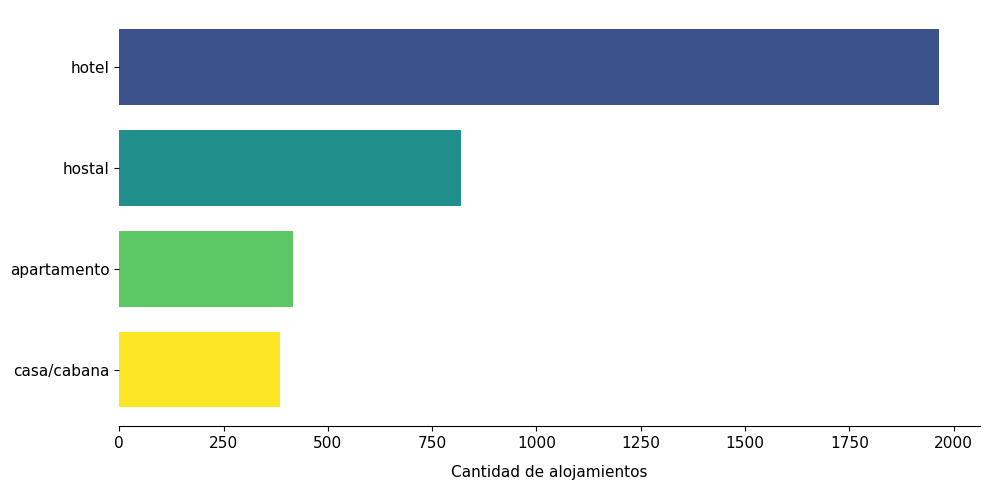

In [13]:
kpi_tipos = (df.groupBy("tipo_alojamiento")
             .agg(F.count("*").alias("cantidad"))
             .withColumn("participacion", F.round(F.col("cantidad") / total * 100, 2))
             .orderBy(F.asc("cantidad"))) # Ascendente para que el más alto quede arriba


kpi_tipos.show()


pandas_tipos = kpi_tipos.toPandas()


import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10, 5))


valores_normalizados = [i / len(pandas_tipos) for i in range(len(pandas_tipos))]
colores_degradado = cm.viridis_r(valores_normalizados) 


barras = ax.barh(pandas_tipos["tipo_alojamiento"], pandas_tipos["cantidad"], color=colores_degradado, height=0.75)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


ax.set_xlabel("Cantidad de alojamientos", fontsize=11, labelpad=10)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()


 *Storytelling Estratégico:*

Los hoteles dominan el mercado con el 54.8% de la oferta, mientras que los hostales son el formato más económico con $47,521 CLP de promedio. Esto le dice a un inversionista dónde está la mayor competencia (el formato saturado) y qué formato está menos explotado y podría representar un nicho con menos rivales.

 *Decisión de Negocio:* Evaluar entrada en segmento de hoteles con diferenciación o explorar nichos menos explotados como cabañas o apartamentos.

---

### Gráfico 3: Participación por segmento (cluster)

+----------+--------+-------------+---------------------------------------+
|prediction|cantidad|participacion|nombre_grupo                           |
+----------+--------+-------------+---------------------------------------+
|0         |1534    |42.8         |Grupo 0 (precio bajo, buena puntuación)|
|1         |1217    |33.96        |Grupo 1 (precio bajo, puntuación menor)|
|2         |833     |23.24        |Grupo 2 (precio alto)                  |
+----------+--------+-------------+---------------------------------------+



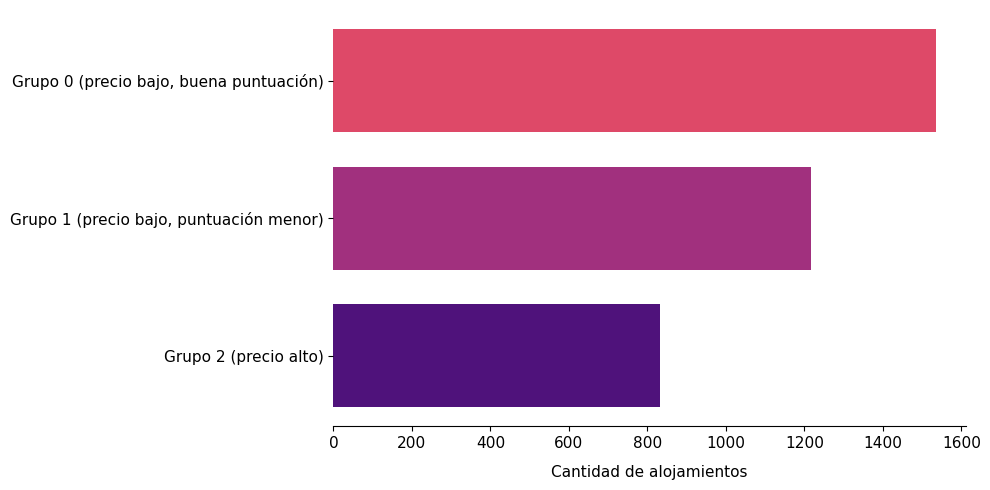

In [14]:
kpi_clusters = (df.groupBy("prediction")
                .agg(F.count("*").alias("cantidad"))
                .withColumn("participacion", F.round(F.col("cantidad") / total * 100, 2))
               
                .withColumn("nombre_grupo", 
                            F.when(F.col("prediction") == 0, "Grupo 0 (precio bajo, buena puntuación)")
                             .when(F.col("prediction") == 1, "Grupo 1 (precio bajo, puntuación menor)")
                             .otherwise("Grupo 2 (precio alto)"))
                
                .orderBy(F.asc("prediction")))


kpi_clusters.show(truncate=False)


pandas_clusters = kpi_clusters.toPandas()


import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10, 5))


valores_normalizados = [i / len(pandas_clusters) for i in range(len(pandas_clusters))]
colores_degradado = cm.magma_r([0.4, 0.55, 0.75])


barras = ax.barh(pandas_clusters["nombre_grupo"], pandas_clusters["cantidad"], color=colores_degradado, height=0.75)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


ax.invert_yaxis()


ax.set_xlabel("Cantidad de alojamientos", fontsize=11, labelpad=10)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()


*Storytelling Estratégico:*

El mercado se divide en tres segmentos. El Grupo 0 (precio bajo y buena puntuación) es el más grande con 42.8% de los alojamientos, mientras que el Grupo 2 (precio alto) es el más pequeño. Para la dirección, el tamaño del Grupo 0 muestra que la mayor parte del mercado ofrece buena calidad a precios accesibles: ahí está el grueso de la demanda y por lo tanto el segmento más relevante para una estrategia de inversión.

 *Decisión de Negocio:* Enfocar la inversión en el segmento con mayor volumen (Grupo 0) o diferenciarse en el segmento Premium (Grupo 2).

## 📈 Nivel Táctico (Gerentes / Analistas)

### Gráfico 4: Rango y dispersión de precios por tipo

+----------------+----------+---------------+----------+
|tipo_alojamiento|precio_min|precio_promedio|precio_max|
+----------------+----------+---------------+----------+
|          hostal|   21844.0|        47521.0|  227400.0|
|     apartamento|   22800.0|        83634.0|  226672.0|
|     casa/cabana|   21844.0|        89940.0|  229344.0|
|           hotel|   21844.0|       110410.0|  229236.0|
+----------------+----------+---------------+----------+



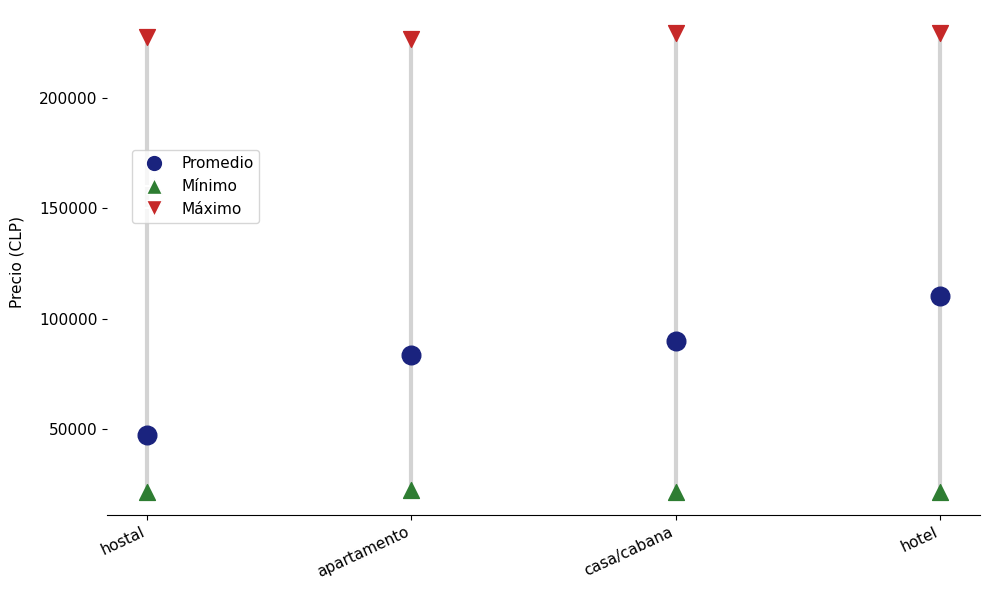

In [15]:
kpi_precio_tipo = (df.groupBy("tipo_alojamiento")
                   .agg(F.min("precio_clp").alias("precio_min"),
                        F.round(F.mean("precio_clp"), 0).alias("precio_promedio"),
                        F.max("precio_clp").alias("precio_max"))
                   .orderBy("precio_promedio"))


kpi_precio_tipo.show()


pandas_precio_tipo = kpi_precio_tipo.toPandas()


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))


for i, row in pandas_precio_tipo.iterrows():
    tipo = row["tipo_alojamiento"]
    
    
    ax.vlines(x=tipo, ymin=row["precio_min"], ymax=row["precio_max"], 
              colors="#d3d3d3", linewidth=3, zorder=1)
    
    
    ax.scatter(tipo, row["precio_min"], color="#2e7d32", marker="^", s=130, zorder=2)
    
   
    ax.scatter(tipo, row["precio_promedio"], color="#1a237e", marker="o", s=180, zorder=3)
    
  
    ax.scatter(tipo, row["precio_max"], color="#c62828", marker="v", s=130, zorder=4)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


ax.set_ylabel("Precio (CLP)", fontsize=11, labelpad=10)
ax.tick_params(axis='both', labelsize=11)
plt.xticks(rotation=25, ha="right")


from matplotlib.lines import Line2D
elementos_leyenda = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1a237e', markersize=12, label='Promedio'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#2e7d32', markersize=11, label='Mínimo'),
    Line2D([0], [0], marker='v', color='w', markerfacecolor='#c62828', markersize=11, label='Máximo')
]
ax.legend(handles=elementos_leyenda, loc="center left", bbox_to_anchor=(0.02, 0.65), fontsize=11)

plt.tight_layout()
plt.show()

📖 *Storytelling Táctico:*

Los hoteles son el tipo más caro (promedio $110,410 CLP) y los hostales el más económico (promedio $47,521 CLP). La gerencia aprovecha esta dispersión para fijar precios donde haya menos competencia y mejor margen.

✅ *Decisión de Negocio:* Definir estrategia de precios según el tipo de alojamiento y la competencia en cada segmento.

---

### Gráfico 5: Precio promedio por ciudad

+--------------+---------------+
|        ciudad|precio_promedio|
+--------------+---------------+
|        Temuco|        76252.0|
|         Talca|        78337.0|
|         Arica|        80025.0|
|       Chillan|        81319.0|
|  Puerto Montt|        85819.0|
|      Valdivia|        86724.0|
|       Iquique|        86960.0|
|     Coyhaique|        87609.0|
|     La Serena|        87974.0|
|  Punta Arenas|        88537.0|
|      Rancagua|        90529.0|
|  Puerto Varas|        93218.0|
|       Copiapo|        93379.0|
|   Antofagasta|        94901.0|
|Puerto Natales|        95693.0|
|    Valparaiso|        96335.0|
|    Concepcion|        96549.0|
|        Calama|        96651.0|
|  Vina del Mar|        97323.0|
|      Santiago|       107259.0|
+--------------+---------------+
only showing top 20 rows



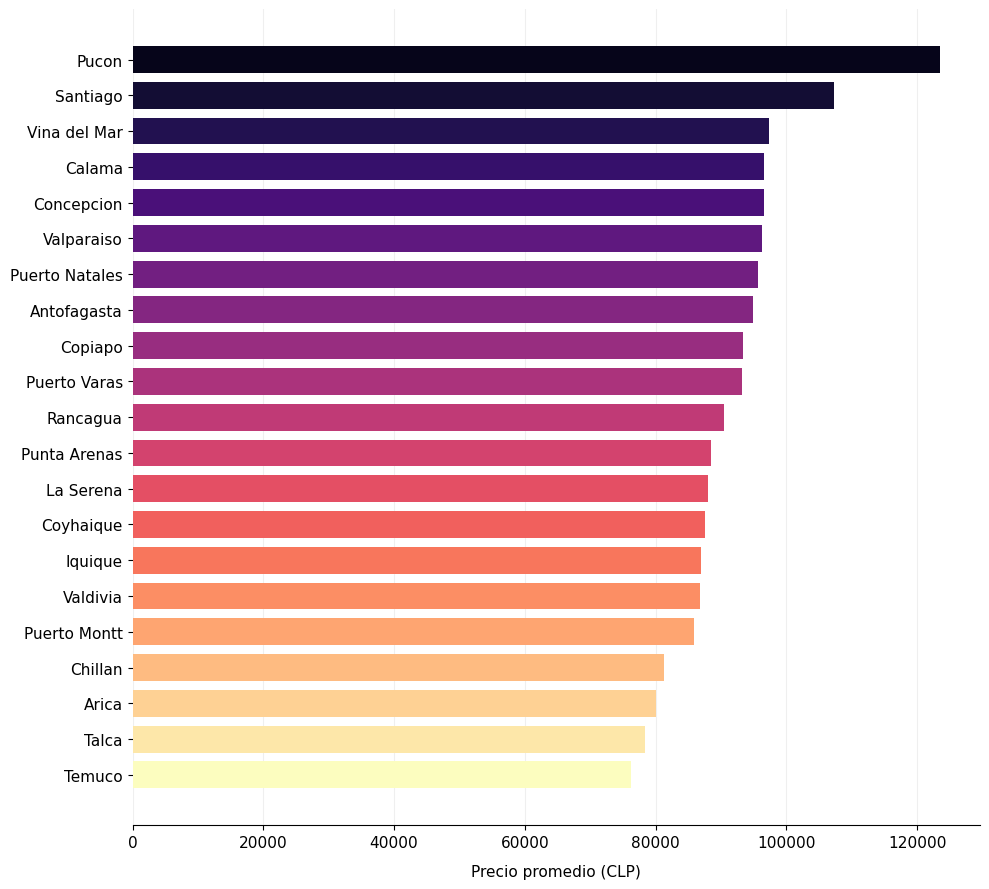

In [16]:
kpi_precio_ciudad = (df.groupBy("ciudad")
                     .agg(F.round(F.mean("precio_clp"), 0).alias("precio_promedio"))
                     .orderBy(F.asc("precio_promedio"))) # Ascendente para que el más alto quede arriba


kpi_precio_ciudad.show()


pandas_precio_ciudad = kpi_precio_ciudad.toPandas()


import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10, 9))


valores_normalizados = [i / len(pandas_precio_ciudad) for i in range(len(pandas_precio_ciudad))]
colores_degradado = cm.magma_r(valores_normalizados)


barras = ax.barh(pandas_precio_ciudad["ciudad"], pandas_precio_ciudad["precio_promedio"], 
                 color=colores_degradado, height=0.75)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


ax.set_xlabel("Precio promedio (CLP)", fontsize=11, labelpad=10)
ax.tick_params(axis='both', labelsize=11)


ax.grid(axis="x", linestyle="-", alpha=0.3, color="#cccccc")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


 *Storytelling Táctico:*

Santiago es la ciudad con precio promedio más alto, mientras que Talca es la más económica. Un inversionista que busca tarifas altas miraría las ciudades caras; uno que busca entrar con precios competitivos y captar volumen miraría las más económicas.

 *Decisión de Negocio:* Seleccionar ciudades objetivo según la estrategia de precios deseada (premium vs. volumen).

---

### Gráfico 6: Precio promedio por segmento (cluster)

+----------+---------------+---------------------------------------+
|prediction|precio_promedio|nombre_grupo                           |
+----------+---------------+---------------------------------------+
|0         |68069.0        |Grupo 0 (precio bajo, buena puntuación)|
|1         |67048.0        |Grupo 1 (precio bajo, puntuación menor)|
|2         |167145.0       |Grupo 2 (precio alto)                  |
+----------+---------------+---------------------------------------+



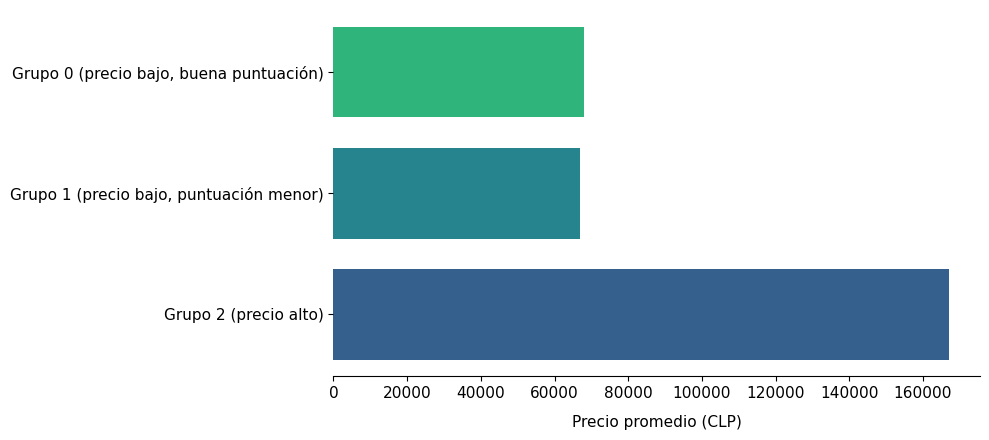

In [17]:
kpi_precio_cluster = (df.groupBy("prediction")
                      .agg(F.round(F.mean("precio_clp"), 0).alias("precio_promedio"))
                      
                      .withColumn("nombre_grupo", 
                                  F.when(F.col("prediction") == 0, "Grupo 0 (precio bajo, buena puntuación)")
                                   .when(F.col("prediction") == 1, "Grupo 1 (precio bajo, puntuación menor)")
                                   .otherwise("Grupo 2 (precio alto)"))
                    
                      .orderBy(F.asc("prediction")))


kpi_precio_cluster.show(truncate=False)


pandas_precio_cluster = kpi_precio_cluster.toPandas()


import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10, 4.5))


colores_degradado = cm.viridis([0.65, 0.45, 0.3]) 


barras = ax.barh(pandas_precio_cluster["nombre_grupo"], pandas_precio_cluster["precio_promedio"], 
                 color=colores_degradado, height=0.75)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


ax.invert_yaxis()


ax.set_xlabel("Precio promedio (CLP)", fontsize=11, labelpad=10)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()


*Storytelling Táctico:*

El Grupo 2 cobra bastante más que los Grupos 0 y 1. Como el Grupo 0 mantiene buena puntuación cobrando poco, el gerente puede definir una estrategia de precios competitivos sin sacrificar calidad.

*Decisión de Negocio:* Posicionamiento en segmento Intermedio o Premium según estrategia de marca.

##  Nivel Operacional (Supervisores)

### Gráfico 7: Salud de la reputación por nivel de puntuación

+------------------+--------+
|             nivel|cantidad|
+------------------+--------+
|    Baja (7.0-7.9)|    1062|
|   Buena (8.5-8.9)|     794|
|Excelente (9.0-10)|     980|
|   Media (8.0-8.4)|     748|
+------------------+--------+



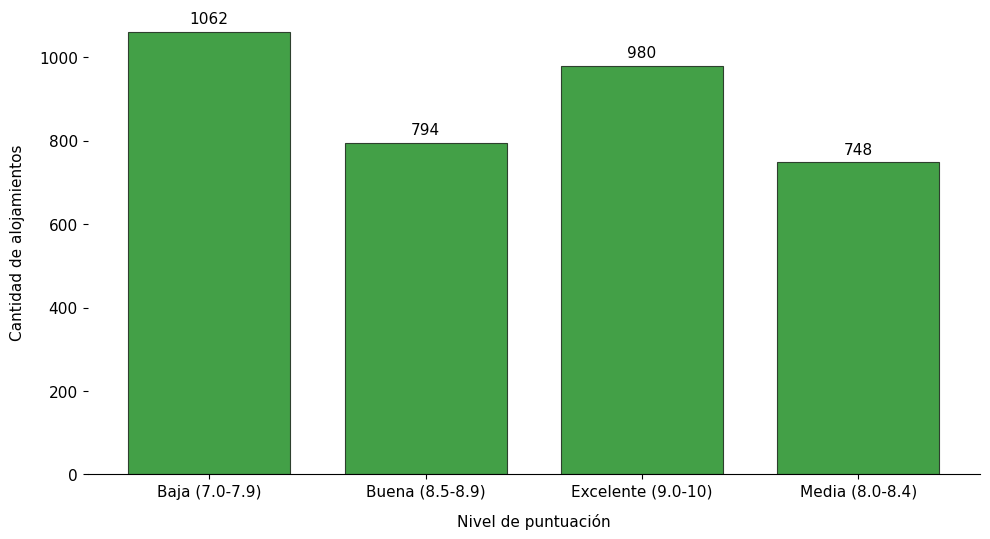

In [18]:
kpi_niveles = (df.withColumn("nivel",
                             F.when(F.col("puntuacion") < 8.0, "Baja (7.0-7.9)")
                             .when(F.col("puntuacion") < 8.5, "Media (8.0-8.4)")
                             .when(F.col("puntuacion") < 9.0, "Buena (8.5-8.9)")
                             .otherwise("Excelente (9.0-10)"))
               .groupBy("nivel")
               .agg(F.count("*").alias("cantidad"))
               .orderBy("nivel"))


kpi_niveles.show()


pandas_niveles = kpi_niveles.toPandas()


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5.5))


barras = ax.bar(pandas_niveles["nivel"], pandas_niveles["cantidad"], 
                color="#43a047", edgecolor="#2e402e", linewidth=0.8, width=0.75)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


ax.set_xlabel("Nivel de puntuación", fontsize=11, labelpad=10)
ax.set_ylabel("Cantidad de alojamientos", fontsize=11, labelpad=10)
ax.tick_params(axis='both', labelsize=11)


for barra in barras:
    alto = barra.get_height()
    ax.annotate(f'{int(alto)}',
                xy=(barra.get_x() + barra.get_width() / 2, alto),
                xytext=(0, 4),  # Desplazamiento de 4 puntos hacia arriba
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()


 *Storytelling Operacional:*

La calidad general es alta (puntuación promedio 8.39; la mayoría en niveles Bueno y Excelente). Se detectaron alojamientos con puntuación bajo 7.5. La supervisión enfoca su atención en los alojamientos bajo el umbral de alerta para corregir su menor desempeño.

 *Decisión de Negocio:* Priorizar alianzas con alojamientos de alta puntuación y evitar aquellos en zona de alerta.

---

### Gráfico 8: Distribución de puntuaciones por tipo

+----------------+-------------------+--------------+--------------+
|tipo_alojamiento|puntuacion_promedio|puntuacion_min|puntuacion_max|
+----------------+-------------------+--------------+--------------+
|     apartamento|               8.32|           6.6|           9.9|
|     casa/cabana|               8.37|           6.6|          10.0|
|          hostal|               8.36|           6.6|          10.0|
|           hotel|               8.42|           6.6|          10.0|
+----------------+-------------------+--------------+--------------+



/tmp/ipykernel_7837/3481370707.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


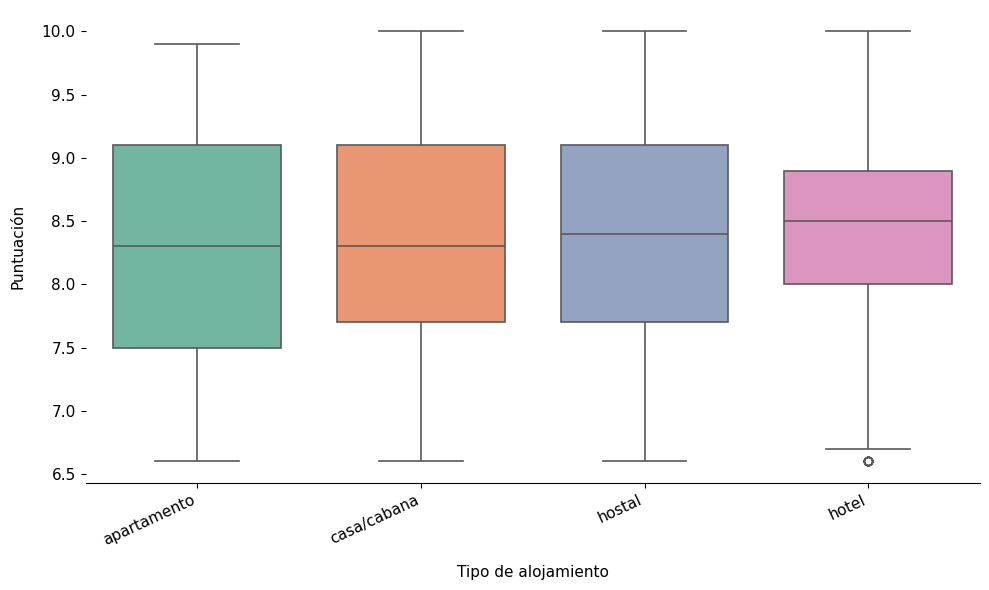

In [19]:
kpi_punt_tipo = (df.groupBy("tipo_alojamiento")
                 .agg(F.round(F.mean("puntuacion"), 2).alias("puntuacion_promedio"),
                      F.min("puntuacion").alias("puntuacion_min"),
                      F.max("puntuacion").alias("puntuacion_max"))
                 .orderBy("tipo_alojamiento"))

kpi_punt_tipo.show()


import seaborn as sns
import matplotlib.pyplot as plt


pandas_completo = df.select("tipo_alojamiento", "puntuacion").toPandas()

fig, ax = plt.subplots(figsize=(10, 6))


colores_pastel = ["#66bb6a", "#ffa726", "#42a5f5", "#ab47bc"] 


sns.boxplot(
    data=pandas_completo, 
    x="tipo_alojamiento", 
    y="puntuacion", 
    ax=ax, 
    palette="Set2",      
    width=0.75,
    linewidth=1.2,
    fliersize=6           
)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


ax.set_xlabel("Tipo de alojamiento", fontsize=11, labelpad=12)
ax.set_ylabel("Puntuación", fontsize=11, labelpad=12)
ax.tick_params(axis='both', labelsize=11)
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

*Storytelling Operacional:*

Los hoteles tienen puntuaciones más consistentes (caja compacta), mientras que los hostales muestran mayor variabilidad. Un tipo con caja alta y compacta es una apuesta más segura en calidad; uno con caja larga tiene experiencias muy dispares, lo que implica más riesgo para el inversionista.

*Decisión de Negocio:* Para una entrada segura, priorizar tipos con menor variabilidad en puntuación.

---

### Gráfico 9: Cantidad de alertas por ciudad

+--------------+-------+
|        ciudad|alertas|
+--------------+-------+
|         Pucon|      7|
|Puerto Natales|     19|
|        Temuco|     21|
|  Punta Arenas|     21|
|         Talca|     22|
|     Coyhaique|     23|
|      Santiago|     23|
|       Iquique|     25|
|    Concepcion|     26|
|  Vina del Mar|     26|
|    Valparaiso|     27|
|         Arica|     28|
|  Puerto Varas|     28|
|       Chillan|     28|
|     La Serena|     29|
|  Puerto Montt|     29|
|       Copiapo|     31|
|      Rancagua|     32|
|      Valdivia|     35|
|        Calama|     38|
+--------------+-------+
only showing top 20 rows



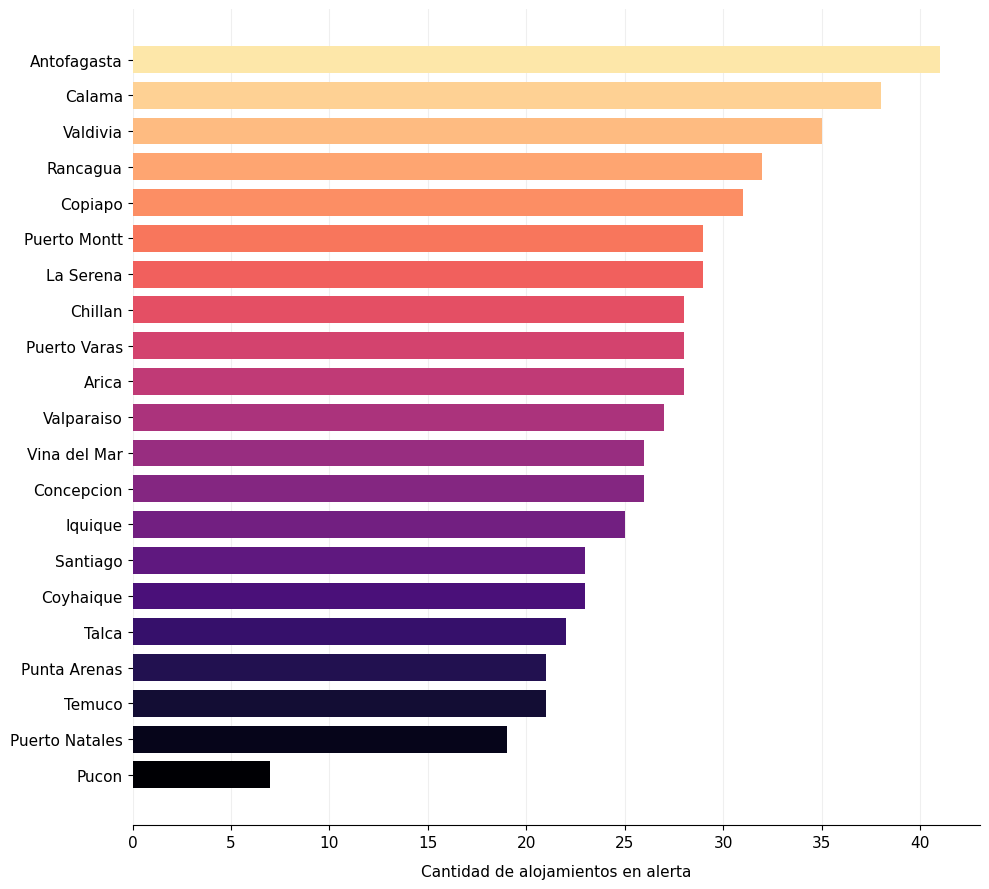

In [20]:
umbral = 7.5
kpi_alertas = (df.filter(F.col("puntuacion") < umbral)
               .groupBy("ciudad")
               .agg(F.count("*").alias("alertas"))
               .orderBy(F.asc("alertas")))


kpi_alertas.show()


pandas_alertas = kpi_alertas.toPandas()


import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10, 9))


valores_normalizados = [i / len(pandas_alertas) for i in range(len(pandas_alertas))]
colores_degradado = cm.magma(valores_normalizados) 


barras = ax.barh(pandas_alertas["ciudad"], pandas_alertas["alertas"], 
                 color=colores_degradado, height=0.75)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


ax.set_xlabel("Cantidad de alojamientos en alerta", fontsize=11, labelpad=10)
ax.tick_params(axis='both', labelsize=11)


ax.grid(axis="x", linestyle="-", alpha=0.3, color="#cccccc")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


 *Storytelling Operacional:*

Santiago es la ciudad con más alojamientos bajo el umbral de alerta. Esto le dice al supervisor en qué ciudad concentrar la revisión de calidad. Para un inversionista, una ciudad con muchas alertas puede significar competencia débil en calidad: una oportunidad para entrar con un alojamiento bien evaluado y destacar.

 *Decisión de Negocio:* Concentrar esfuerzos de calidad en ciudades con más alertas o identificar oportunidades de diferenciación.

##  Conclusiones y Recomendaciones

### 1. MERCADO CHILENO DE ALOJAMIENTOS

- *3,584* alojamientos analizados
- Precio promedio: *$90,750 CLP* por noche
- Puntuación promedio: *8.39/10* (calidad alta)
- *Hoteles* dominan el mercado (54.8% de la oferta)
- *Grupo 0* representa el 42.8% del mercado (precio bajo, buena calidad)

### 2. OPORTUNIDADES DE INVERSIÓN

- *Grupo 0 (42.8%):* precio bajo y buena calidad → mayor oportunidad
- Ciudades con menor oferta: oportunidad de entrada con menos competencia
- *Hostales:* formato más económico, ideal para estrategia de volumen
- *Hoteles:* mayor margen potencial pero más competencia

### 3. RECOMENDACIONES ESTRATÉGICAS

| # | Recomendación | Fundamentos |
|---|---------------|-------------|
| 1 | Enfocarse en ciudades con alta demanda y baja oferta | Menor competencia, mayor margen |
| 2 | Priorizar alojamientos con puntuación > 8.0 | Calidad asegurada, menor riesgo |
| 3 | Diferenciación en segmento de hoteles | Mayor margen, marca premium |
| 4 | Evitar ciudades saturadas como Santiago | Alta competencia, menor rentabilidad |

### 4. PRÓXIMOS PASOS

1. Ampliar cobertura a más ciudades intermedias
2. Implementar sistema de monitoreo de precios en tiempo real
3. Desarrollar estrategia de precios dinámicos por zona
4. Establecer alianzas con alojamientos de alta puntuación

---

##  Fin del Informe Final

*Proyecto Final - Market Intelligence*  
*Grupo G5 - Turismo y Hotelería*  
*Junio 2026*